# 醫療影像辨識

醫療期間: 到院診斷 == 離院 == 追蹤(難)(期望改善)

# 深度學習應用在醫療影像三大主題 

***Classification(是否有病)***

***segamentation(圈出病狀面積，大小)***

***detection(找出病症位置)***



# 醫療影像種類

1. ***X-ray*** 反衰減(硬器官-->白)

2. ***超音波*** 反射，不做頭和肺(頭(硬)-->全反射。肺(軟)-->零反射)

3. ***CT*** (血管:測鈣化。窄。剝離)(全身CT+PET:測腫瘤)(腦)

4. ***CTA*** 血管路經追蹤 --> 3D

5. ***MRI*** 氫原子順磁-->高色頻 (動 == 糊)(不做肺)

6. ***SPECT*** gamma_ray (依照對比劑，功能不同)

7. ***PET*** 顯影劑阻止葡萄糖糖解(亮--> Concerned)(膀胱，腦，心)

# 醫療影像限制

1. ***無法比對*** EX:超音波，醫生技術好壞成像差很多。

2. ***參數沒統一***

3. ***標籤少*** 病患不提供隱私 + 醫生很忙難抽出時間label 


# Neural Network : input間建立線性組合 + 與target建立非線性關係 (用以模擬現實)

***diagram***

two stage (feedfoward)

***input X=(x1......xp)***
***output Y=(y1......yk) if Y 連續 -->回歸。if Y discrete。Sum(Y1...yk)==1 -->分類。*** 

input layer ---> hidden layer ---> fully_connected(最後一層activated) ---> output


# 線性組合 a0 + sigma(ai*xi) 



# 非線性組合(activate function)

***layer1 : H = activated(a0 + sigma(ai*xi) )*** 

***線性組合 B0 + sigma(Bi*Hi)***
***Output: Yk = fully_connected(B0 + sigma(Bi*Hi))***

# Layer越多(deep)-關係越複雜-解決更難問題

activated function 

1. sigmoid 1 / (1+e**-sv)  s可調整

2. relu max(0,v) 計算快，但不可微分

fully connected ***(看y決定)

1. 回歸 : gk(T) = Tk

2. 分類 :  gk(T) = e**(TK) / sigman(e** Tl)



# 要做幾層 -- 經驗法則。越多可能overfittng

# 要幾個hidden unit。越多越好，但可能收斂。

# 超參數如何決定?? 優化

In [1]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from pydicom import dcmread
import os
import cv2
 # Keras specific
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D


Using TensorFlow backend.


In [2]:
#load train.csv
df = pd.read_csv('C:/Users/James/Downloads/hwk01_data/hwk01_data/train.csv')
df

,ID,Age,Gender,FilePath,index,Stage
0,A175204,69,0,/DICOM/A175204/00010018,7,1
1,A122221,56,0,/DICOM/A122221/00010034,15,1
2,A54671,82,0,/DICOM/A54671/00010021,8,1
3,A31117,71,1,/DICOM/A31117/00010022,10,1
4,A653195,68,0,/DICOM/A653195/00010016,7,1
...,...,...,...,...,...,...
156,A717094,80,1,/DICOM/A717094/00010022,11,3
157,A741758,54,1,/DICOM/A741758/00010017,9,3
158,A646753,75,1,/DICOM/A646753/00010023,12,3
159,A679904,62,1,/DICOM/A679904/00010020,9,3


In [3]:
#rewrite file path
x = [i for i in df['FilePath']] 

for i in range(len(x)):
    x[i] = x[i].replace('/','\\')

In [4]:
#create new filename and new path
file_name = []
for i in range(len(x)):
    s = x[i]
    s = s.split('\\') #split strings
    file_name.append(s[-1]) #list append filename
    s.pop()
    x[i] = '\\'.join(map(str,s)) # new filepath

In [5]:
# adding new cols to df
df['filepath'] = x
df['file_name'] = file_name

In [6]:
df

,ID,Age,Gender,FilePath,index,Stage,filepath,file_name
0,A175204,69,0,/DICOM/A175204/00010018,7,1,\DICOM\A175204,00010018
1,A122221,56,0,/DICOM/A122221/00010034,15,1,\DICOM\A122221,00010034
2,A54671,82,0,/DICOM/A54671/00010021,8,1,\DICOM\A54671,00010021
3,A31117,71,1,/DICOM/A31117/00010022,10,1,\DICOM\A31117,00010022
4,A653195,68,0,/DICOM/A653195/00010016,7,1,\DICOM\A653195,00010016
...,...,...,...,...,...,...,...,...
156,A717094,80,1,/DICOM/A717094/00010022,11,3,\DICOM\A717094,00010022
157,A741758,54,1,/DICOM/A741758/00010017,9,3,\DICOM\A741758,00010017
158,A646753,75,1,/DICOM/A646753/00010023,12,3,\DICOM\A646753,00010023
159,A679904,62,1,/DICOM/A679904/00010020,9,3,\DICOM\A679904,00010020


In [7]:
#get label(y)
label = np.array(df['Stage'])

In [8]:
# 記住目前目錄
x = os.getcwd()
x

'C:\\Users\\James'

In [9]:
#loading image data (train_data)
data = []
for i in range(len(df)):
    filepath = x + df['filepath'][i] #設定path = 當前目錄 + filepath
    os.chdir(filepath) #到指定資料夾
    ds = dcmread(df['file_name'][i]) #read dicom
    arr = ds.pixel_array # read image
    arr = arr[(df['index'][i])-1] #根據train.csv提供index選圖片，python從0開始，csv_index從1開始，故減1
    arr = arr[39:89,39:89] #crop image ，將圖片切成50*50 去掉無用黑背景
    image = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR) #將圖片轉成RGB 3 channel
    data.append(image)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


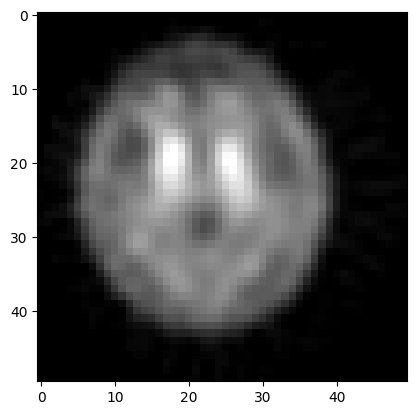

In [10]:
import matplotlib.pyplot as plt
# 檢視匯入影像
plt.imshow(data[0])
plt.show()

In [11]:
X1 = np.array(data) #轉為np

In [12]:
X1.shape # training data shape 161張50*50*3channel

(161, 50, 50, 3)

In [13]:
X1 = preprocess_input(X1) #特徵縮放，每個特徵減掉該特徵的平均數

In [14]:
print(label.shape)
label = label.reshape(161,1) #change label shape

(161,)


In [15]:
label = to_categorical(label) #因為是multi classification ， output 3個類別。change to to_categorical 最後output應有3個node
label #套件多算一個node 0 

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],


In [16]:
label = label[:, 1:]
label

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1

In [17]:
# preparing second training input(gender and age)
X2 = df[['Age','Gender']]

In [18]:
X2= np.array(X2)


In [19]:
os.chdir('C:\\Users\\James')#reset filepath


In [20]:
# testing data
df2 = pd.read_csv('test.csv')
df2

,ID,Age,Gender,FilePath,index,Stage 1,Stage 2,Stage 3,Stage
0,A152206,64,1,/DICOM/A152206/00010023,11,NaN,NaN,NaN,NaN
1,A42278,72,1,/DICOM/A42278/00010022,10,NaN,NaN,NaN,NaN
2,A306881,89,0,/DICOM/A306881/00010033,19,NaN,NaN,NaN,NaN
3,A289458,44,0,/DICOM/A289458/00010035,16,NaN,NaN,NaN,NaN
4,A518725,72,0,/DICOM/A518725/00010022,9,NaN,NaN,NaN,NaN
5,A737619,56,1,/DICOM/A737619/00010023,10,NaN,NaN,NaN,NaN
6,A194289,74,1,/DICOM/A194289/00010023,9,NaN,NaN,NaN,NaN
7,A741991,71,1,/DICOM/A741991/00010021,7,NaN,NaN,NaN,NaN
8,A29870,79,0,/DICOM/A29870/00010019,6,NaN,NaN,NaN,NaN
9,X691,39,0,/DICOM/X691/00010023,10,NaN,NaN,NaN,NaN


In [21]:
#loading testing image
x = [i for i in df2['FilePath']] 
#rewrite file path
for i in range(len(x)):
    x[i] = x[i].replace('/','\\')
#create filename and path
file_name = []
for i in range(len(x)):
    s = x[i]
    s = s.split('\\')
    file_name.append(s[-1])
    s.pop()
    x[i] = '\\'.join(map(str,s))
# adding to df
df2['filepath'] = x
df2['file_name'] = file_name

data2 = []
for i in range(len(df2)):
    filepath = 'C:\\Users\\James' + df2['filepath'][i] #設定path
    os.chdir(filepath) #到指定資料夾
    ds = dcmread(df2['file_name'][i]) #read dicom
    arr = ds.pixel_array # read image
    arr = arr[(df2['index'][i])-1] #根據index選圖片
    arr = arr[39:89,39:89] #轉成50*50 去掉無用黑背景
    image = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR) #轉成 3 channel
    data2.append(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


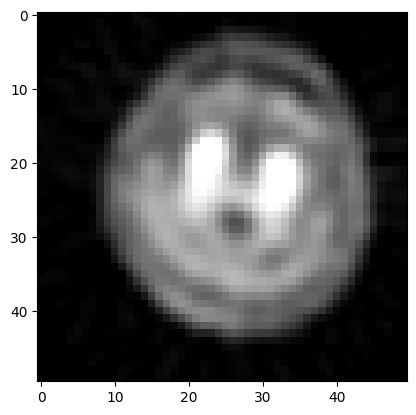

In [22]:
import matplotlib.pyplot as plt
# 檢視匯入影像
plt.imshow(data2[0])
plt.show()

In [23]:
X1_test = np.array(data2) #change to np

In [24]:
X1_test.shape # 41筆testing data size 50*50*3

(41, 50, 50, 3)

In [25]:
# preparing second testing input(gender and age)
X2_test = df2[['Age','Gender']]
X2_test = np.array(X2_test)

In [26]:
X2_test.shape #check shape

(41, 2)

In [ ]:
#=============================建立模型==================================
#目標是train 兩個 model ，一個cnn model負責 train圖片 ，一個 mlp model負責 train age gender。
#最後將兩個模型concatenate ，再通過兩層fully-connected layer來預測output
#cnn model 分別採用vgg16 和 resnet50 (ImageNet pretrained)，not included top3 layer。

In [28]:
# 定義 mlp_model
def mlp():
    model = Sequential() #採keras sequential model
    model.add(Dense(64, activation='relu', input_dim=X2.shape[1])) #input layer，input dim == 2 (age,gender)，output 64units
    model.add(Dense(32, activation='relu')) # hidden layer，output 32units
    model.add(Dense(8, activation='relu')) # hidden layer，output 8units
    return model


In [29]:
#定義 vgg16 model
def vgg16():
    base_model = VGG16(weights='imagenet', include_top=False)#不包含後三層fully-connected layer(imagenet)，自行定義後三層dense layer
    x = base_model.output # x為經過vgg16 預設5block之output 
    x = GlobalAveragePooling2D()(x) # x要先flattern by avg pooling
    x = layers.Dense(256, activation='relu')(x) #自行定義dense layer
    x = layers.Dense(128, activation='relu')(x) #自行定義dense layer
    x = layers.Dense(64, activation='relu')(x) #自行定義dense layer
    # 設定新模型的架構
    model = Model(inputs=base_model.input, outputs=x)

    # VGG16 原有的層均不重新訓練
    for layer in base_model.layers:
        layer.trainable = False
    return model

In [30]:
# mlp summary
mlp = mlp()
mlp.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                192       
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 8)                 264       
Total params: 2,536
Trainable params: 2,536
Non-trainable params: 0
_________________________________________________________________


In [31]:
# vgg16 summary，model = pretrain 5 block + avg_pooling + 自訂 3 dense layer
vgg = vgg16()
vgg.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, None, None, 3)]   0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, None, None, 64)    1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, None, None, 64)    36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, None, None, 64)    0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, None, None, 128)   73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, None, None, 128)   147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, None, None, 128)  

In [32]:
#concatenate 2 models 
from keras.layers import concatenate

combinedInput = concatenate([mlp.output, vgg.output]) #concatenate vgg.mlp output as new input
x = Dense(2048, activation="relu")(combinedInput) # adding dense layer
x = Dense(1024, activation="relu")(x) # adding dense layer
x = Dense(3, activation="softmax")(x) # softmax to predict probability of stage (output == 3)
model = Model(inputs=[mlp.input, vgg.input], outputs=x) # new model architecture
#因為是分類問題，loss_function採'categorical_crossentropy' 優化採用 rmsprop
model.compile(loss='categorical_crossentropy',optimizer='rmsprop', metrics=['accuracy']) 
model.summary() #完整 model summary


Model: "functional_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
block1_conv1 (Conv2D)           (None, None, None, 6 1792        input_1[0][0]                    
__________________________________________________________________________________________________
block1_conv2 (Conv2D)           (None, None, None, 6 36928       block1_conv1[0][0]               
__________________________________________________________________________________________________
block1_pool (MaxPooling2D)      (None, None, None, 6 0           block1_conv2[0][0]               
_______________________________________________________________________________________

In [33]:
# train the model
print("training")
#fitting model , mlp input (X2)  vgg input(X1) y=labels(3stage) ，setting epochs = 100(跑整組資料100次) batch_size=50(一次50張)
history = model.fit(
     x=[X2, X1], y = label,
     epochs=40, batch_size=50)

print("finished...")
preds = model.predict([X2_test, X1_test]) # predicting labels fo testing data



training
Epoch 1/40
4/4 [==============================] - 1s 134ms/step - loss: 25.8634 - accuracy: 0.3416
Epoch 2/40
4/4 [==============================] - 1s 130ms/step - loss: 3.1707 - accuracy: 0.4037
Epoch 3/40
4/4 [==============================] - 0s 122ms/step - loss: 0.9979 - accuracy: 0.4596
Epoch 4/40
4/4 [==============================] - 1s 130ms/step - loss: 0.9985 - accuracy: 0.4907
Epoch 5/40
4/4 [==============================] - 1s 137ms/step - loss: 1.0928 - accuracy: 0.6087
Epoch 6/40
4/4 [==============================] - 1s 127ms/step - loss: 1.5281 - accuracy: 0.5155
Epoch 7/40
4/4 [==============================] - 1s 128ms/step - loss: 0.9769 - accuracy: 0.5901
Epoch 8/40
4/4 [==============================] - 1s 127ms/step - loss: 1.1171 - accuracy: 0.4534
Epoch 9/40
4/4 [==============================] - 1s 133ms/step - loss: 0.8626 - accuracy: 0.5963
Epoch 10/40
4/4 [==============================] - 1s 141ms/step - loss: 0.8136 - accuracy: 0.6149
Epoch 11/

In [34]:
preds # 預測testing data之機率

array([[7.10996866e-01, 2.33349666e-01, 5.56534454e-02],
       [6.40665650e-01, 2.74032176e-01, 8.53021666e-02],
       [4.73298371e-01, 4.33889598e-01, 9.28119645e-02],
       [5.43658078e-01, 3.14972043e-01, 1.41369864e-01],
       [9.44081008e-01, 4.46565337e-02, 1.12625696e-02],
       [5.82311150e-05, 3.44861438e-03, 9.96493161e-01],
       [4.22766447e-01, 4.92762357e-01, 8.44711661e-02],
       [1.94895387e-01, 2.95538813e-01, 5.09565771e-01],
       [8.97487640e-01, 8.31445605e-02, 1.93677898e-02],
       [9.99311686e-01, 4.26916697e-04, 2.61380919e-04],
       [2.66642068e-02, 1.49310336e-01, 8.24025452e-01],
       [5.31763434e-01, 3.05121779e-01, 1.63114801e-01],
       [9.98238802e-01, 1.52458542e-03, 2.36523978e-04],
       [9.86642838e-01, 9.36292578e-03, 3.99432052e-03],
       [9.99603093e-01, 1.08375265e-04, 2.88565556e-04],
       [5.57475030e-01, 3.46469849e-01, 9.60551649e-02],
       [4.26772326e-01, 4.01742399e-01, 1.71485215e-01],
       [4.20553535e-01, 3.76015

In [35]:
preds = np.around(preds, decimals=2) #四捨五入到小數點第二位

In [36]:
preds

array([[0.71, 0.23, 0.06],
       [0.64, 0.27, 0.09],
       [0.47, 0.43, 0.09],
       [0.54, 0.31, 0.14],
       [0.94, 0.04, 0.01],
       [0.  , 0.  , 1.  ],
       [0.42, 0.49, 0.08],
       [0.19, 0.3 , 0.51],
       [0.9 , 0.08, 0.02],
       [1.  , 0.  , 0.  ],
       [0.03, 0.15, 0.82],
       [0.53, 0.31, 0.16],
       [1.  , 0.  , 0.  ],
       [0.99, 0.01, 0.  ],
       [1.  , 0.  , 0.  ],
       [0.56, 0.35, 0.1 ],
       [0.43, 0.4 , 0.17],
       [0.42, 0.38, 0.2 ],
       [0.32, 0.47, 0.21],
       [0.74, 0.17, 0.09],
       [0.39, 0.38, 0.23],
       [1.  , 0.  , 0.  ],
       [0.95, 0.04, 0.01],
       [0.35, 0.47, 0.18],
       [0.64, 0.25, 0.11],
       [0.42, 0.39, 0.18],
       [0.6 , 0.28, 0.12],
       [0.71, 0.21, 0.08],
       [0.04, 0.3 , 0.66],
       [0.95, 0.04, 0.01],
       [0.92, 0.06, 0.02],
       [0.22, 0.61, 0.17],
       [0.99, 0.01, 0.  ],
       [0.95, 0.04, 0.01],
       [0.72, 0.23, 0.05],
       [0.94, 0.05, 0.01],
       [0.47, 0.34, 0.19],
 

In [37]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


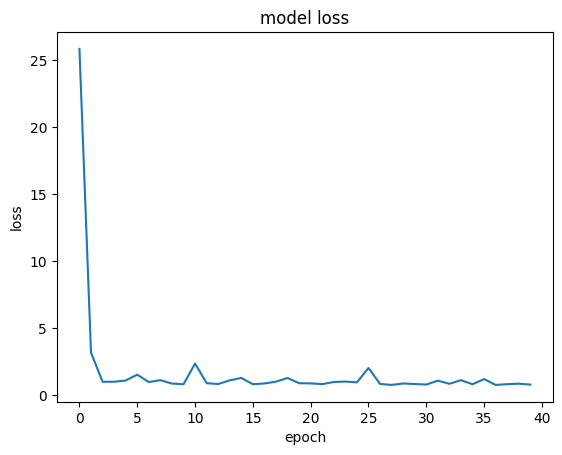

In [38]:
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

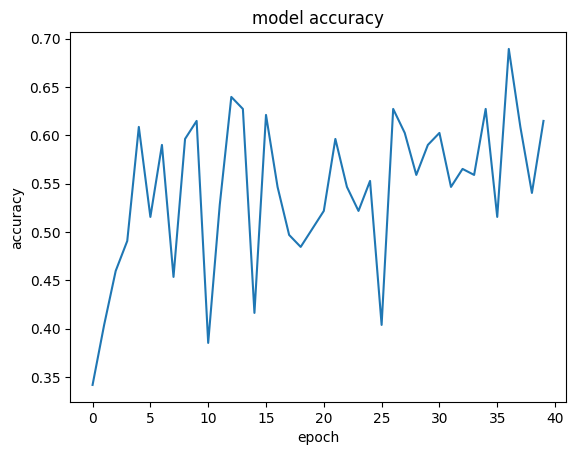

In [39]:
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

In [40]:
result_vgg = pd.DataFrame(preds, columns = ['1','2','3'])
result_vgg

,1,2,3
0,0.71,0.23,0.06
1,0.64,0.27,0.09
2,0.47,0.43,0.09
3,0.54,0.31,0.14
4,0.94,0.04,0.01
5,0.00,0.00,1.00
6,0.42,0.49,0.08
7,0.19,0.30,0.51
8,0.90,0.08,0.02
9,1.00,0.00,0.00


In [41]:
maxValueIndex = result_vgg.idxmax(axis=1)
result_vgg['Stage'] = maxValueIndex

In [42]:
result_vgg = result_vgg.rename({'1': 'Stage1', '2': 'Stage2','3': 'Stage3'}, axis=1)  # new method

In [43]:
from pathlib import Path  
filepath = Path('C:\\Users\\James\\out.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
result_vgg.to_csv(filepath) 

In [44]:
#====================== resnet 50 ======================================================

In [45]:
from keras.applications.resnet50 import ResNet50
input_shape = (50, 50, 3)
resMod = ResNet50(include_top=False, weights='imagenet',input_shape=input_shape)

num_classes = 3
x = resMod.layers[-1].output
x = Flatten(name='flatten')(x)
x = Dropout(0.5)(x)
x = Dense(3, activation='softmax')(x)
# Create your own model 
net = Model(inputs=resMod.input, outputs=x) 
net.summary()

Model: "functional_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 50, 50, 3)]  0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 56, 56, 3)    0           input_2[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 25, 25, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 25, 25, 64)   256         conv1_conv[0][0]                 
_______________________________________________________________________________________

In [46]:
#concatenate

combinedInput = concatenate([mlp.output, net.output]) #concatenate vgg.mlp output as new input
x = Dense(1024, activation="relu")(combinedInput) # adding dense layer
x = Dense(512, activation="relu")(x) # adding dense layer
x = Dense(3, activation="softmax")(x) # softmax to predict probability of stage (output == 3)
model2 = Model(inputs=[mlp.input, net.input], outputs=x) # new model architecture
#因為是分類問題，loss_function採'categorical_crossentropy' 優化採用 rmsprop
model2.compile(loss='categorical_crossentropy',optimizer='adam', metrics=['accuracy']) 
model2.summary() #完整 model summary



Model: "functional_7"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 50, 50, 3)]  0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 56, 56, 3)    0           input_2[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 25, 25, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 25, 25, 64)   256         conv1_conv[0][0]                 
_______________________________________________________________________________________

In [47]:
# train the model
print("training")
#fitting model , mlp input (X2)  vgg input(X1) y=labels(3stage) ，setting epochs = 60(跑整組資料60次) batch_size=50(一次50張)
history2 = model2.fit(
     x=[X2, X1], y = label,
     epochs=60, batch_size=50)

print("finished...")
preds2 = model2.predict([X2_test, X1_test]) # predicting labels fo testing data


training
Epoch 1/60
4/4 [==============================] - 4s 1s/step - loss: 1.4262 - accuracy: 0.4410
Epoch 2/60
4/4 [==============================] - 4s 1s/step - loss: 1.1820 - accuracy: 0.2733
Epoch 3/60
4/4 [==============================] - 4s 1s/step - loss: 1.0561 - accuracy: 0.5652
Epoch 4/60
4/4 [==============================] - 4s 919ms/step - loss: 1.0671 - accuracy: 0.4472
Epoch 5/60
4/4 [==============================] - 4s 938ms/step - loss: 1.0562 - accuracy: 0.4410
Epoch 6/60
4/4 [==============================] - 4s 876ms/step - loss: 1.0648 - accuracy: 0.4534
Epoch 7/60
4/4 [==============================] - 3s 832ms/step - loss: 1.0574 - accuracy: 0.4720
Epoch 8/60
4/4 [==============================] - 4s 993ms/step - loss: 1.0727 - accuracy: 0.4286
Epoch 9/60
4/4 [==============================] - 4s 959ms/step - loss: 1.0663 - accuracy: 0.4286
Epoch 10/60
4/4 [==============================] - 4s 975ms/step - loss: 1.0504 - accuracy: 0.4658
Epoch 11/60
4/4 [==

In [48]:
preds2

array([[0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.8700161 , 0.1272275 , 0.00275638],
       [0.

In [49]:
preds2 = np.around(preds2, decimals=2) #四捨五入到小數點第二位
preds2

array([[0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
       [0.87, 0.13, 0.  ],
 

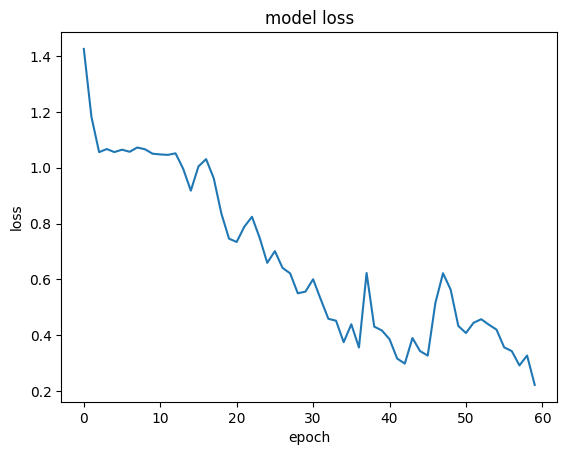

In [50]:
plt.plot(history2.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

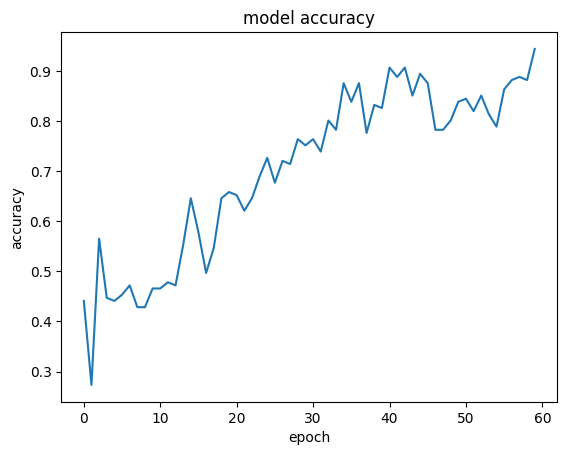

In [51]:
plt.plot(history2.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()